# FL16Y spectral fitting implemented by PixelTable

In [47]:
%reset -f
%run pylib/tools dark
from pylib.tools import np, plt, pd
from pathlib import Path
from importlib import reload
from astropy.coordinates import SkyCoord
from utilities.ipynb_docgen import show, show_date
from like3 import pixel_table as pixel_table_mod; reload(pixel_table_mod)
PixelTable = pixel_table_mod.PixelTable
from like3 import sourcelist as sourcelist_mod; reload(sourcelist_mod)
SourceModel = sourcelist_mod.SourceModel

show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-04-08 08:11</h5>

## Build a SourceModel From a Fermi catalog subset

Use the FL16Y catalog to create a compact ROI source model around a trial position. This supports the new `SourceModel.from_fermi_catalog(...)` entry point with spatial filtering, `query=`, and explicit `select=`.

In [48]:
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog('uw1617',

    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)

selected_name = roi_sources.source_names[0]

show(
    f'''Loaded {len(roi_sources)} catalog sources within {cone_size} deg of {roi_center.to_string("decimal", precision=3)}.
First selected source: {selected_name}'''
)

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


Loaded 1 catalog sources within 1.0 deg of 98.476 17.770.
First selected source: PSRJ0633+1746

## Create a PixelTable with this SourceModel

In [49]:
pixtab = PixelTable('files/kerr/toby_v4.fits', source_model=roi_sources)

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 1 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from 'files/loc'


## Fit the parameters

{'hess': array([[5152646.07382451, 1847399.50612034],
        [1847399.50612034, 1851652.97580365]]),
 'cov': array([[ 3.02161336e-07, -3.01467235e-07],
        [-3.01467235e-07,  8.40832727e-07]]),
 'sigs': array([0.0005, 0.0009]),
 'corr': array([[ 1. , -0.6],
        [-0.6,  1. ]]),
 'grad': array([18.15603498, -6.34140108]),
 'x_fit': array([-10.29886455,   0.75923116]),
 'x_init': array([-9.5324597 ,  2.04286003]),
 'delta_loglike': 44197958.97,
 'ts_values': array([5506657.4,       nan])}

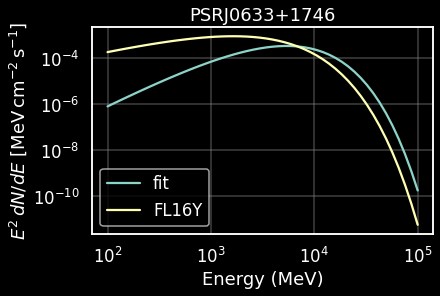

In [55]:
# test spectral fitting on the first source in the list using the full energy range
src = roi_sources[0] # the source 
fig, ax = plt.subplots(figsize=(6,4))
with pixtab.preserve_parameters():
    pixtab.fit()
    pixtab.source_model.sed_plot(ax=ax, label='fit')
    new_flux_func = src.model.copy()
pixtab.source_model.sed_plot(ax=ax, label='FL16Y');
show(pixtab.fit_info)


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7a1247ecf4c0>
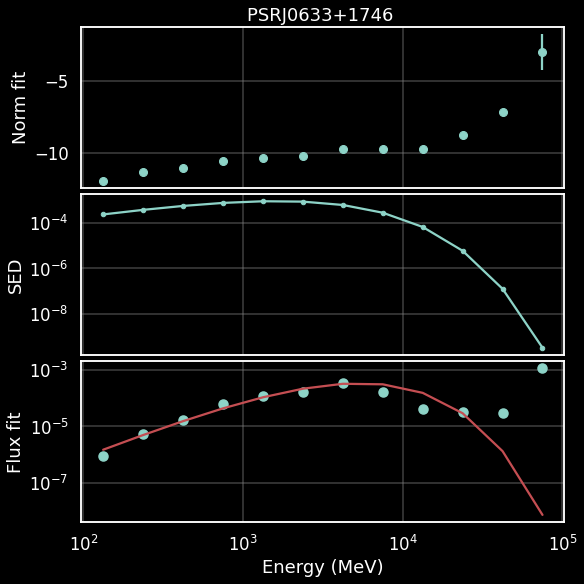

In [ ]:
import pandas as pd

# --- Norm prof: fit only the normalization for each energy bin ---
# Group all bands by energy index (second element of band key); each group
# contains up to 4 PSF-type bands that share the same energy boundaries.


energy_indices = sorted({k[1] for k in pixtab.keys()})
src = pixtab.source_model[0] # the source we just fit above; should be the same as roi_sources[0]
flux_func = src.model.copy()
rows = []
with pixtab.preserve_parameters():
    for e_idx in energy_indices:
        keys = [k for k in pixtab.keys() if k[1] == e_idx]
        pixtab.select(keys=keys)
        pixtab.fit([0])
        band0 = pixtab[keys[0]]
        e_mev = np.sqrt(band0.e0 * band0.e1).round()
        x_fit  = pixtab.fit_info['x_fit'][0].round(3)
        sig    = pixtab.fit_info['sigs'][0].round(3)
        ts_val = pixtab.fit_info['ts_values'][0]
        rows.append(dict(e_idx=e_idx, e_mev=e_mev, x_fit=x_fit, sig=sig, 
                         ts=ts_val, sed=flux_func(e_mev)*e_mev**2))

pixtab.select()   # reset to all bands

prof = pd.DataFrame(rows)
fig, axx = plt.subplots(3,1, figsize=(8,8), sharex=True)
ax,ax2,ax3 = axx
ax.errorbar(prof['e_mev'], prof['x_fit'], yerr=prof['sig'], fmt='o', markersize=8)
ax.set_xscale('log')
# ax2.set_xlabel('Energy (MeV)')
ax.set_ylabel('Norm fit')
ax.set_title(f'{selected_name} ')
e_mev = prof['e_mev']
ax2.plot(prof['e_mev'], prof['sed'], '.-', )#label='FL16Y SED')
# ax2.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), '+', label='Norm fit SED')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylabel('SED')#r'$E^2\,dN/dE\ [\mathrm{MeV\,cm^{-2}\,s^{-1}}]$')
# ax2.legend()
ax3.scatter(prof.e_mev, 10**prof.x_fit * prof.sed/flux_func['Norm'], )# label='flux fit')
ax3.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), 'r', label='Norm fit SED')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_ylabel('Flux fit')
ax3.set_xlabel('Energy (MeV)')
# ax3.legend()
show(fig)

In [53]:
pixtab.source_model[0].model

Norm      : 2.93e-10 
Index     : 2.04 
Curvature : 0.727 (FROZEN)
b         : 0.678 (FROZEN)

## Study of band Band(2, 4): PSF2@1.33 GeV nside 128 occ 0.999

### Model and data for Geminga

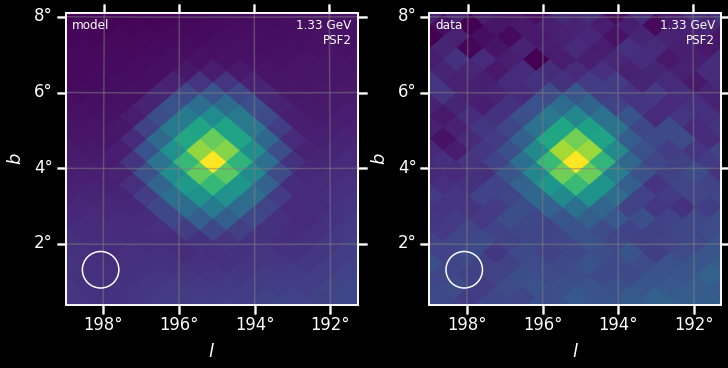

In [6]:
import matplotlib.pyplot as plt
b = pixtab[2,4]
show(f"""## Study of band {b}""")
show(f""" ### Model and data for {roi_name}""")
fig = plt.figure(figsize=(10, 5))
sf1,sf2 = fig.subfigures(ncols=2)
b.zea_plot(roi_center, 'model',  log=True,  axes_visible=True, colorbar=False,fig=sf1,)
b.zea_plot(roi_center, 'data',   log=True,  axes_visible=True, colorbar=False,fig=sf2,)
# plt.tight_layout()
plt.show()

In [10]:
s = pixtab.source_model[0]; s.model

Norm      : 2.93e-10 
Index     : 2.04 
Curvature : 0.727 (FROZEN)
b         : 0.678 (FROZEN)

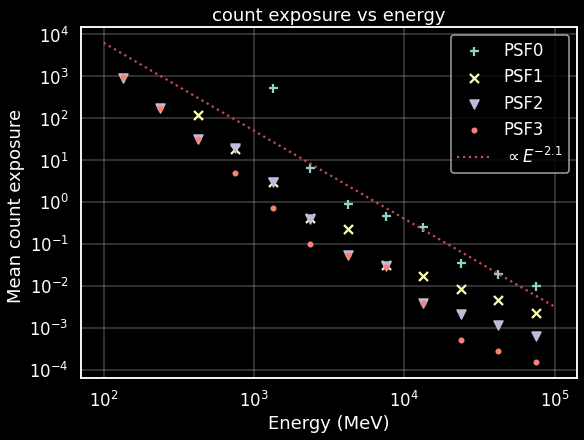

In [70]:
# for each band in pixtab, compute the mean value of the exposure in the pixels, and plot it against the energy of the band. 
energies = []
exposures = []
psf_index = []

for b in pixtab.values():
    energies.append(np.sqrt(b.e0 * b.e1))
    exposures.append(b.count_exposure.mean())
    psf_index.append(b.key[0])
plt.figure(figsize=(8,6))
for index, char in enumerate('+xv.'):
    mask = np.array(psf_index) == index
    plt.scatter(np.array(energies)[mask], np.array(exposures)[mask],  marker=char, 
                label=f'PSF{index}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (MeV)')
plt.ylabel('Mean count exposure ')
plt.title(f'count exposure vs energy')


ax = plt.gca()
ax.plot((x:=np.logspace(2,5,100)), 1e8 * x**(-2.1), 'r:', label=r'$\propto E^{-2.1}$')
plt.legend();